EDA Student Peroformance Indicator

In [ ]:
# 1) Problem statement
# This project understand how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, 
# Parental level of education, Lunch and Test preparation course.

# 2) Data collection
# The data consists of 8 columns and 1000 rows.

# 3) Dataset Information
# gender: sex of students -> (Male/Female)
# race/ethnicity : ethnicity of students -> (Group A, B , C, D, E)
# parental level of education: parents' final education -> (bachelor's degree, some college, master's degree, associate;s degree, high school)
# lunch : having lunch before  test (standard or free/reduced)
# test preparation course : complete or not complete before test
# math score
# reading score
# writing score

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('stud.csv')
df


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Female,Group D,high school,free/reduced,completed,19,69,53
1,Female,Group B,master's degree,free/reduced,completed,80,48,54
2,Female,Group C,high school,free/reduced,none,10,54,47
3,Male,Group B,some college,free/reduced,completed,15,76,72
4,Female,Group D,high school,standard,completed,100,30,71
...,...,...,...,...,...,...,...,...
995,Male,Group A,high school,standard,completed,31,90,43
996,Female,Group A,some college,free/reduced,completed,16,76,90
997,Male,Group D,high school,free/reduced,none,81,87,95
998,Male,Group B,high school,standard,none,55,37,35


In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Female,Group D,high school,free/reduced,completed,19,69,53
1,Female,Group B,master's degree,free/reduced,completed,80,48,54
2,Female,Group C,high school,free/reduced,none,10,54,47
3,Male,Group B,some college,free/reduced,completed,15,76,72
4,Female,Group D,high school,standard,completed,100,30,71


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
df.shape

(1000, 8)

DATA  Checks to perform

In [8]:
# check missing values

df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
# check missing values
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
# check duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
# check data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [12]:
# check the number of unique of each column
df.nunique()

gender                           2
race/ethnicity                   5
parental level of education      5
lunch                            2
test preparation course          2
math score                     101
reading score                  101
writing score                  101
dtype: int64

In [13]:
# check statistics of data set
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,50.33500,51.075000,51.040000
std,29.35927,29.225939,28.988355
min,0.00000,0.000000,0.000000
25%,25.00000,26.000000,26.000000
50%,50.00000,51.000000,52.000000
75%,77.00000,76.250000,76.000000
max,100.00000,100.000000,100.000000


In [14]:
#  explore more info about the data
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Female,Group D,high school,free/reduced,completed,19,69,53
1,Female,Group B,master's degree,free/reduced,completed,80,48,54
2,Female,Group C,high school,free/reduced,none,10,54,47
3,Male,Group B,some college,free/reduced,completed,15,76,72
4,Female,Group D,high school,standard,completed,100,30,71


In [15]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,Male,Group A,high school,standard,completed,31,90,43
996,Female,Group A,some college,free/reduced,completed,16,76,90
997,Male,Group D,high school,free/reduced,none,81,87,95
998,Male,Group B,high school,standard,none,55,37,35
999,Female,Group E,high school,free/reduced,none,2,46,97


In [16]:
# check various categories present in the different categorical column
[feature for feature in df.columns ]

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course',
 'math score',
 'reading score',
 'writing score']

In [17]:
[feature for feature in df.columns if df[feature].dtype =='O']

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course']

In [18]:
#  segreegate the categorical and numerical data
numerical_features =[feature for feature in df.columns if df[feature].dtype !='O']
numerical_features


['math score', 'reading score', 'writing score']

In [19]:
categorical_features = [feature for  feature in df.columns if df[feature].dtype =='O']
categorical_features

['gender',
 'race/ethnicity',
 'parental level of education',
 'lunch',
 'test preparation course']

In [20]:
df['gender'].value_counts()

gender
Male      517
Female    483
Name: count, dtype: int64

In [21]:
df['race/ethnicity'].value_counts()

race/ethnicity
Group A    225
Group E    220
Group D    213
Group B    174
Group C    168
Name: count, dtype: int64

In [22]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,Female,Group D,high school,free/reduced,completed,19,69,53
1,Female,Group B,master's degree,free/reduced,completed,80,48,54
2,Female,Group C,high school,free/reduced,none,10,54,47
3,Male,Group B,some college,free/reduced,completed,15,76,72
4,Female,Group D,high school,standard,completed,100,30,71


In [23]:
#  aggregate the  total score with mean
df['total_score'] = (df['math score']+df['reading score']+df['writing score'])
df['average']= df['total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,Female,Group D,high school,free/reduced,completed,19,69,53,141,47.000000
1,Female,Group B,master's degree,free/reduced,completed,80,48,54,182,60.666667
2,Female,Group C,high school,free/reduced,none,10,54,47,111,37.000000
3,Male,Group B,some college,free/reduced,completed,15,76,72,163,54.333333
4,Female,Group D,high school,standard,completed,100,30,71,201,67.000000


In [24]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
995,Male,Group A,high school,standard,completed,31,90,43,164,54.666667
996,Female,Group A,some college,free/reduced,completed,16,76,90,182,60.666667
997,Male,Group D,high school,free/reduced,none,81,87,95,263,87.666667
998,Male,Group B,high school,standard,none,55,37,35,127,42.333333
999,Female,Group E,high school,free/reduced,none,2,46,97,145,48.333333


<Axes: xlabel='average', ylabel='Count'>

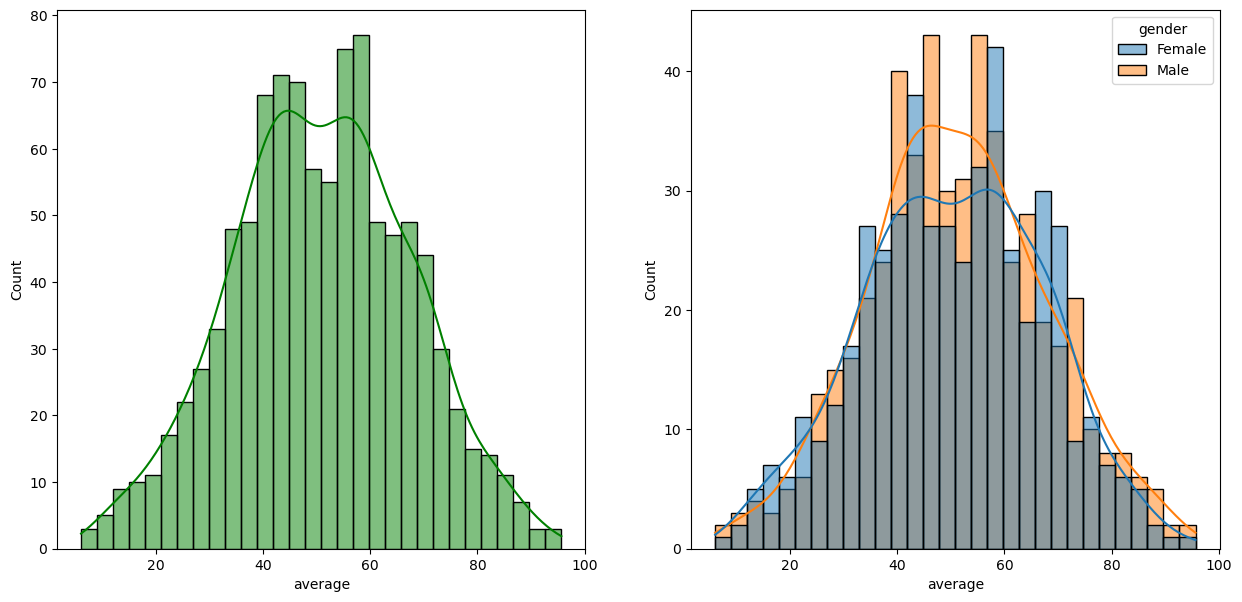

In [25]:
#  Explore with visulization

fix,axis = plt.subplots(1,2,figsize = (15,7))
plt.subplot(121)
sns.histplot(data=df, x ='average', bins = 30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=df, x ='average', bins = 30, kde=True,hue='gender')


In [ ]:
# Insight from above result
#  Male students tend to perform well than the female students

<Axes: xlabel='average', ylabel='Count'>

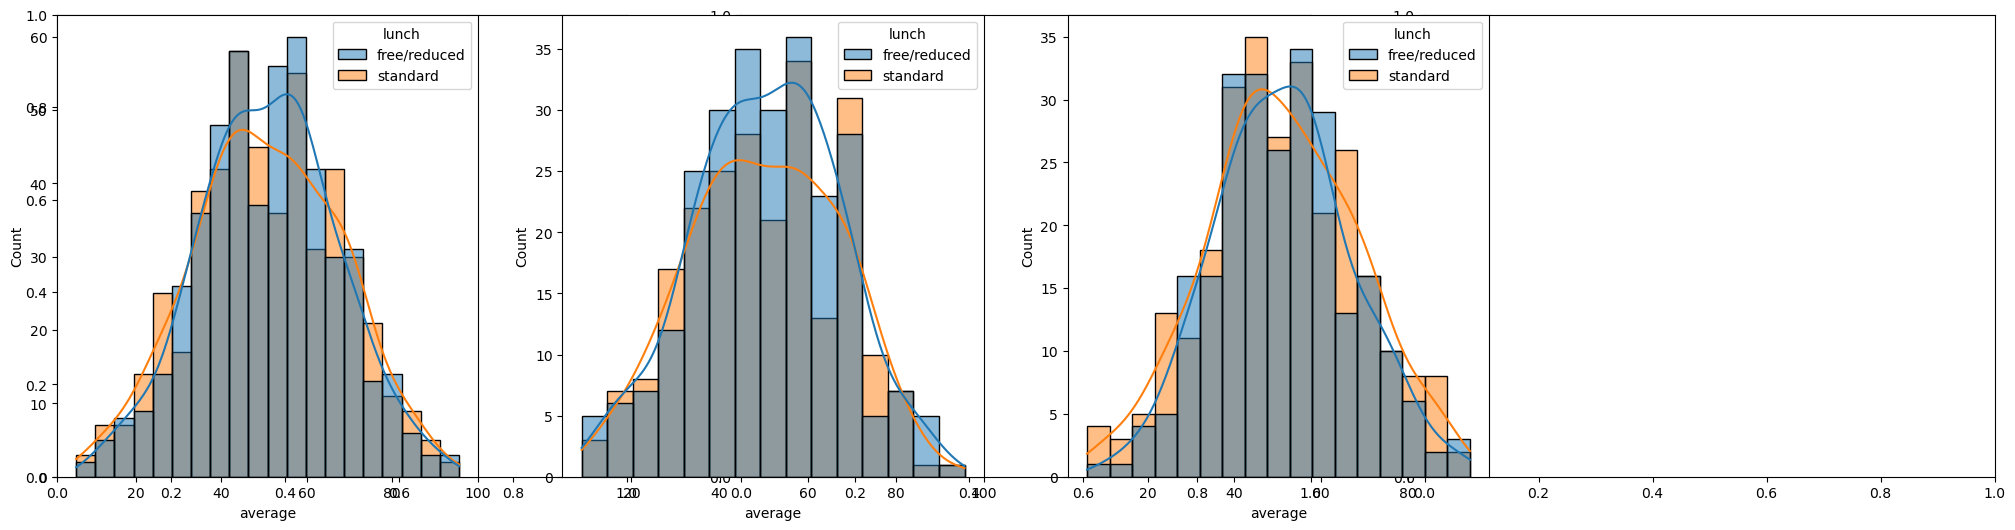

In [29]:
plt.subplots(1,3,figsize = (25,6))
plt.subplot(141)
sns.histplot(data = df, x = 'average', kde = True, hue = 'lunch')
plt.subplot(142)
sns.histplot(data =df[df.gender == 'Female'],x = 'average', kde = True, hue = 'lunch')
plt.subplot(143)
sns.histplot(data =df[df.gender == 'Male'],x = 'average', kde = True, hue = 'lunch')


In [30]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,Female,Group D,high school,free/reduced,completed,19,69,53,141,47.000000
1,Female,Group B,master's degree,free/reduced,completed,80,48,54,182,60.666667
2,Female,Group C,high school,free/reduced,none,10,54,47,111,37.000000
3,Male,Group B,some college,free/reduced,completed,15,76,72,163,54.333333
4,Female,Group D,high school,standard,completed,100,30,71,201,67.000000


<Axes: xlabel='average', ylabel='Count'>

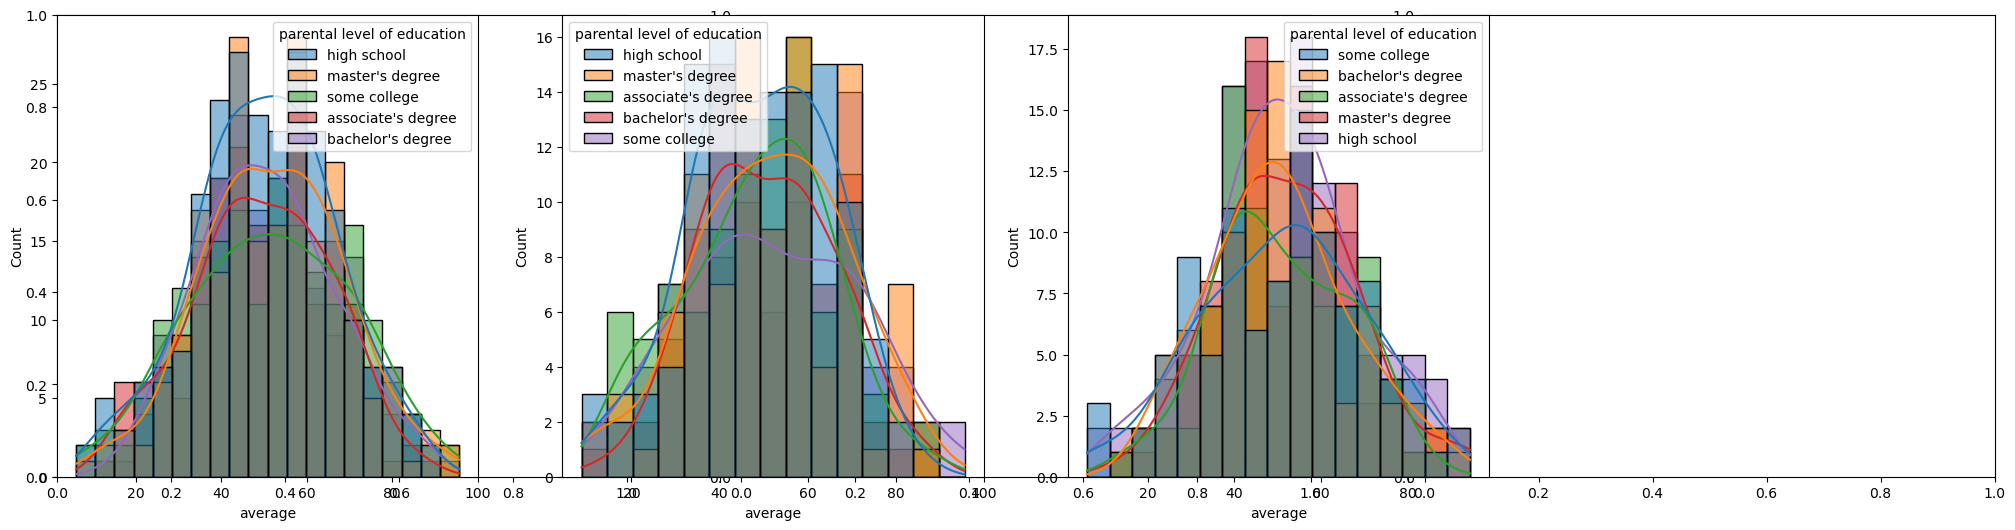

In [32]:
plt.subplots(1,3, figsize = (25,6))
plt.subplot(141)
sns.histplot(data=df, x= 'average', kde = True, hue='parental level of education')
plt.subplot(142)
sns.histplot(data =df[df.gender == 'Female'], x= 'average', kde = True, hue='parental level of education')
plt.subplot(143)
sns.histplot(data =df[df.gender == 'Male'], x= 'average', kde = True, hue='parental level of education')

<Axes: xlabel='average', ylabel='Count'>

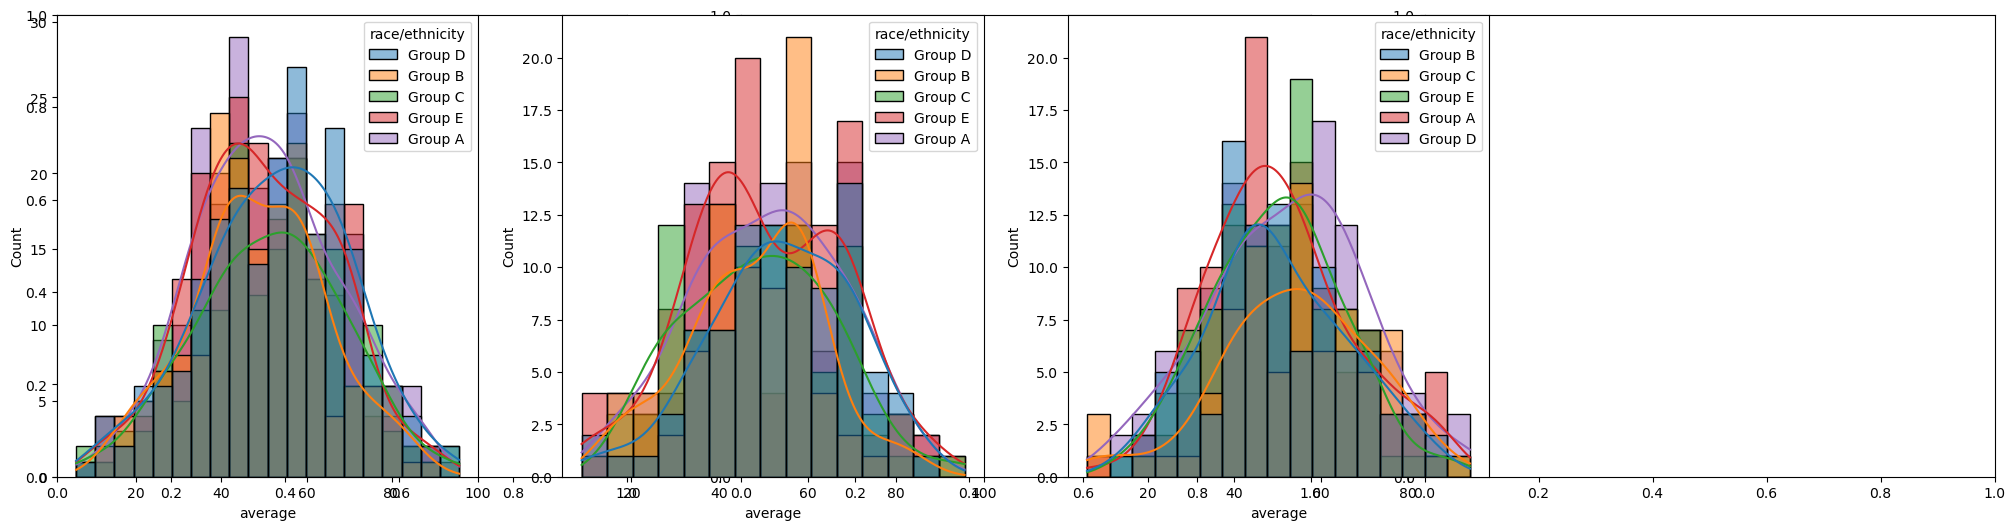

In [33]:
plt.subplots(1,3, figsize = (25,6))
plt.subplot(141)
sns.histplot(data=df, x= 'average', kde = True, hue='race/ethnicity')
plt.subplot(142)
sns.histplot(data =df[df.gender == 'Female'], x= 'average', kde = True, hue='race/ethnicity')
plt.subplot(143)
sns.histplot(data =df[df.gender == 'Male'], x= 'average', kde = True, hue='race/ethnicity')

In [34]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,Female,Group D,high school,free/reduced,completed,19,69,53,141,47.000000
1,Female,Group B,master's degree,free/reduced,completed,80,48,54,182,60.666667
2,Female,Group C,high school,free/reduced,none,10,54,47,111,37.000000
3,Male,Group B,some college,free/reduced,completed,15,76,72,163,54.333333
4,Female,Group D,high school,standard,completed,100,30,71,201,67.000000


In [44]:
df.select_dtypes(include='number').corr()

,math score,reading score,writing score,total_score,average
math score,1.000000,0.009177,0.011333,0.599907,0.599907
reading score,0.009177,1.000000,-0.057862,0.557092,0.557092
writing score,0.011333,-0.057862,1.000000,0.553326,0.553326
total_score,0.599907,0.557092,0.553326,1.000000,1.000000
average,0.599907,0.557092,0.553326,1.000000,1.000000


<Axes: >

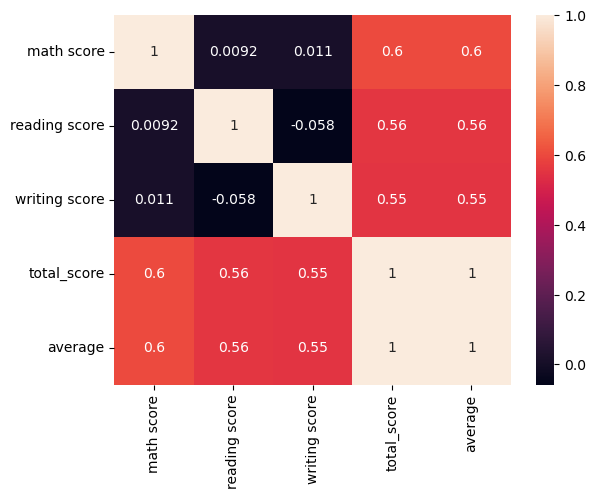

In [46]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)